# EDA of the WWF LPD 2024 Data - Direction B: Population Forecasting

**Objective:** Exploratory Data Analysis for population forecasting based on the Living Planet Database 2024

**Approach:**
1. Dataset Overview & Structure
2. Data Quality Assessment
3. Species & Geographic Distribution
4. Temporal Analysis (Time series coverage)
5. Population Trends & Patterns
6. Sample Time Series Analysis
7. Key Features & Dimensions for Forecasting
8. Conclusions & Next Steps

---
# 0 - SETUP

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the WWF LPD 2024 dataset
df = pd.read_csv('../data/raw/WWF_LPD_2024_public.csv')

print("=" * 80)
print("WWF LIVING PLANET DATABASE 2024 - POPULATION FORECASTING EDA")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Records: {df.shape[0]}")
print(f"Features: {df.shape[1]}")

WWF LIVING PLANET DATABASE 2024 - POPULATION FORECASTING EDA

Dataset Shape: (35996, 103)
Records: 35996
Features: 103


## 1. Dataset Overview & Structure

In [3]:
# Display column information
print("\nColumn Names and Data Types:")
print("-" * 80)
print(df.dtypes.value_counts())

print("\nFirst few columns:")
print(df.columns[:15].tolist())

print("\nFirst few rows:")
df.head()


Column Names and Data Types:
--------------------------------------------------------------------------------
float64    74
object     24
int64       5
Name: count, dtype: int64

First few columns:
['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name', 'Location', 'Country', 'All_countries']

First few rows:


,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,...,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
0,1,Balearica_regulorum,1,0,"Pomeroy, D. and P. Mwima (2002). The State of ...",Aves,Gruiformes,Gruidae,Balearica,regulorum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
1,2,Acrocephalus_sechellensis,1,0,"Rands, M. (1989). ""Saving the Seychelles brush...",Aves,Passeriformes,Acrocephalidae,Acrocephalus,sechellensis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
2,3,Copsychus_sechellarum,1,0,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
3,4,Copsychus_sechellarum,0,1,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,5,Falco_punctatus,0,1,"Groombridge, J. J., Bruford, M.W., Jones, C.G,...",Aves,Falconiformes,Falconidae,Falco,punctatus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [4]:
# Identify year columns (population data)
year_cols = [col for col in df.columns if col.isdigit()]
print(f"\nYear Columns Available: {sorted(year_cols)}")
print(f"Time Range: {min(year_cols)} - {max(year_cols)}")
print(f"Number of Years: {len(year_cols)}")

# Display metadata columns
metadata_cols = ['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation', 'Country', 'Continent', 'Common name']
print("\nMetadata Columns Available:")
for col in metadata_cols:
    if col in df.columns:
        print(f"  ✓ {col}")
    else:
        print(f"  ✗ {col}")

# Print all available columns for reference
print("\nAll Columns in the Dataset:")
for col in df.columns:
    print(f"  - {col}")


Year Columns Available: ['1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']
Time Range: 1950 - 2020
Number of Years: 71

Metadata Columns Available:
  ✓ ID
  ✓ Binomial
  ✓ Replicate
  ✓ Included in LPR2024
  ✓ Citation
  ✓ Country
  ✗ Continent
  ✗ Common name

All Columns in the Dataset:
  - ID
  - Binomial
  - Replicate
  - Included in LPR2024
  - Citation
  - Class
  - Order
  - Family
  - Genus
  - Species
  - Subspecies
  - Common_name
  - Location
  - Country
  - All_cou

## 2. Data Quality Assessment


Missing Values Analysis:
--------------------------------------------------------------------------------

Top 15 Columns with Missing Values:
  Unnamed: 102                    35996 (100.0%)
  1951                            35751 ( 99.3%)
  1950                            35731 ( 99.3%)
  1953                            35711 ( 99.2%)
  1952                            35706 ( 99.2%)
  1954                            35693 ( 99.2%)
  1955                            35671 ( 99.1%)
  1957                            35656 ( 99.1%)
  1956                            35625 ( 99.0%)
  1958                            35614 ( 98.9%)
  1959                            35569 ( 98.8%)
  1960                            35389 ( 98.3%)
  1961                            35348 ( 98.2%)
  1962                            35336 ( 98.2%)
  1963                            35305 ( 98.1%)

Missing Values in Population Years:
  1950:  35731 ( 99.3%)
  1951:  35751 ( 99.3%)
  1952:  35706 ( 99.2%)
  1953:  357

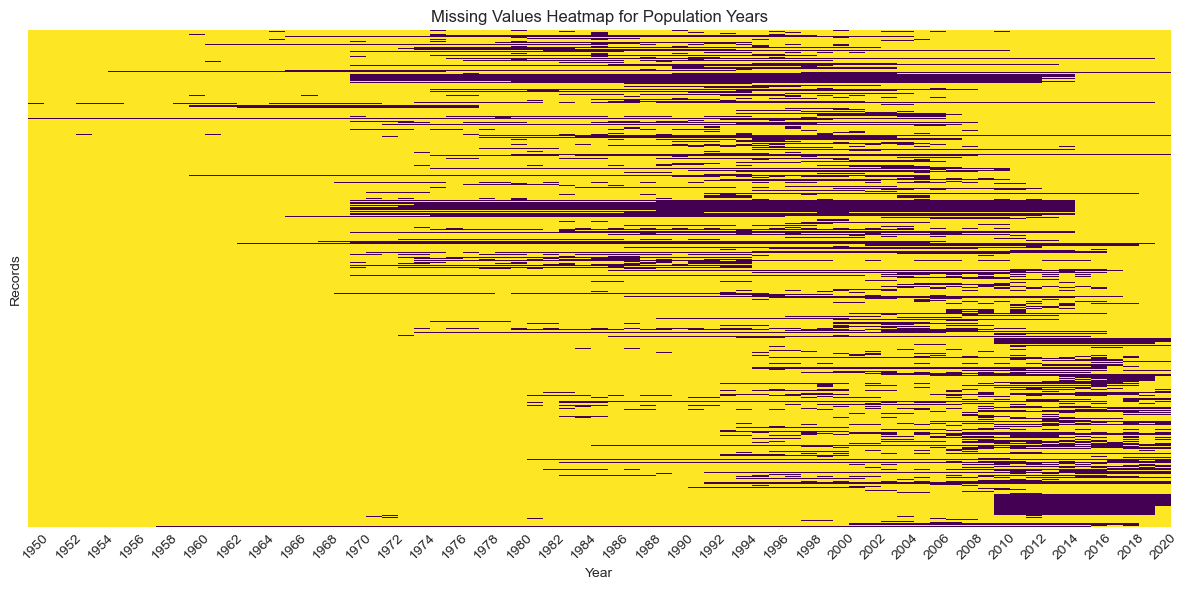

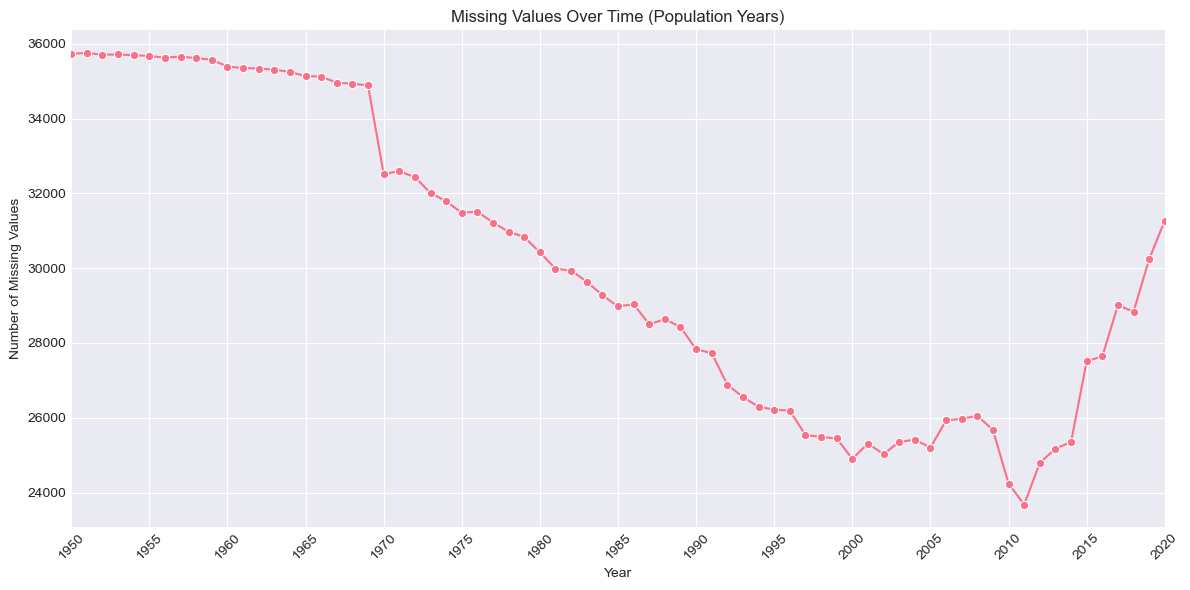

In [26]:
# Missing values analysis
print("\nMissing Values Analysis:")
print("-" * 80)
missing_summary = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

# Show top columns with missing values
top_missing = missing_summary.nlargest(15)
print("\nTop 15 Columns with Missing Values:")
for col, count in top_missing.items():
    pct = (count / len(df)) * 100
    print(f"  {col:30} {count:6} ({pct:5.1f}%)")

# Missing values in year columns 
print("\nMissing Values in Population Years:")
for year in sorted(year_cols):
    missing_count = df[year].isnull().sum()
    missing_pct = (missing_count / len(df)) * 100
    print(f"  {year}: {missing_count:6} ({missing_pct:5.1f}%)")

# Print best year with least missing values
best_year = min(year_cols, key=lambda y: df[y].isnull().sum())
best_year_missing = df[best_year].isnull().sum()
best_year_pct = (best_year_missing / len(df)) * 100
print(f"\nBest Year for Population Data: {best_year} with {best_year_missing} missing values ({best_year_pct:.1f}%)")    

# Plot missingness heatmap for year columns
plt.figure(figsize=(12, 6))
sns.heatmap(df[year_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap for Population Years')
plt.xlabel('Year')
plt.ylabel('Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Missing data over time
missing_over_time = df[year_cols].isnull().sum()
years = missing_over_time.index.astype(int)
plt.figure(figsize=(12, 6))
sns.lineplot(x=years, y=missing_over_time.values, marker='o')
plt.title('Missing Values Over Time (Population Years)')
plt.xlabel('Year')
plt.ylabel('Number of Missing Values')
tick_years = [y for y in years if y % 5 == 0]
plt.xticks(tick_years, rotation=45)
plt.xlim(years.min(), years.max())
plt.tight_layout()
plt.show()


0s Values Analysis in Population Years:
  1950:     24 (  0.1%)
  1951:     23 (  0.1%)
  1952:     19 (  0.1%)
  1953:     20 (  0.1%)
  1954:     19 (  0.1%)
  1955:     23 (  0.1%)
  1956:     26 (  0.1%)
  1957:     17 (  0.0%)
  1958:     23 (  0.1%)
  1959:     26 (  0.1%)
  1960:     39 (  0.1%)
  1961:     33 (  0.1%)
  1962:     24 (  0.1%)
  1963:     22 (  0.1%)
  1964:     34 (  0.1%)
  1965:     37 (  0.1%)
  1966:     34 (  0.1%)
  1967:     33 (  0.1%)
  1968:     40 (  0.1%)
  1969:     32 (  0.1%)
  1970:     77 (  0.2%)
  1971:     68 (  0.2%)
  1972:     73 (  0.2%)
  1973:     81 (  0.2%)
  1974:     73 (  0.2%)
  1975:     91 (  0.3%)
  1976:     79 (  0.2%)
  1977:     70 (  0.2%)
  1978:     76 (  0.2%)
  1979:     91 (  0.3%)
  1980:     97 (  0.3%)
  1981:    260 (  0.7%)
  1982:    292 (  0.8%)
  1983:    259 (  0.7%)
  1984:    337 (  0.9%)
  1985:    397 (  1.1%)
  1986:    294 (  0.8%)
  1987:    328 (  0.9%)
  1988:    344 (  1.0%)
  1989:    317 (  0.9%)

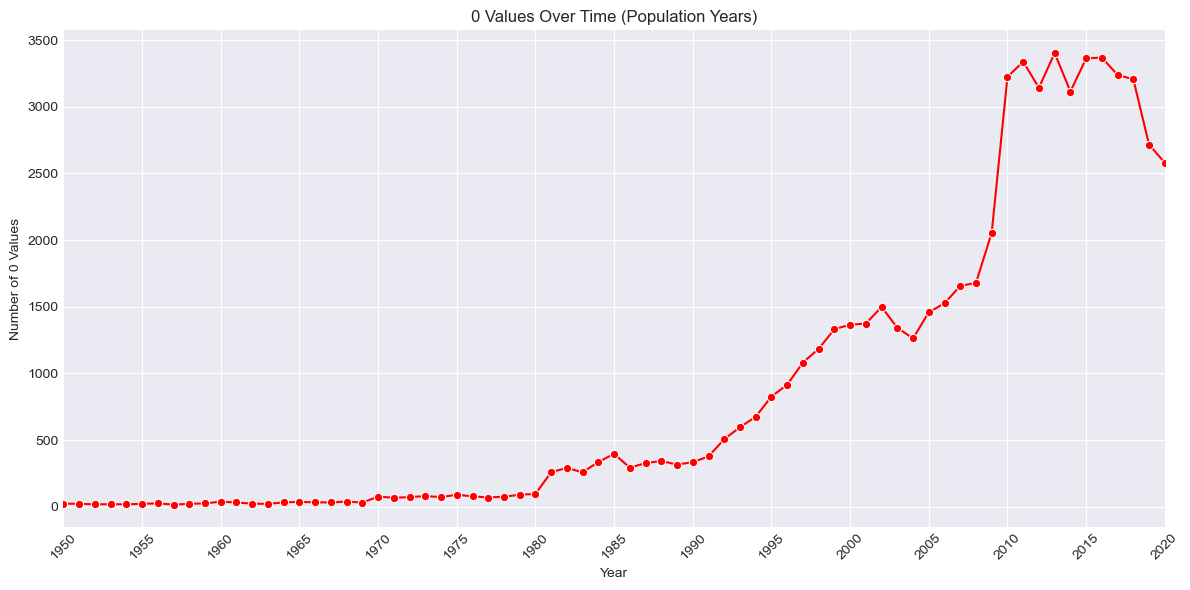

In [42]:
# 0s values analysis
print("\n0s Values Analysis in Population Years:")
for year in sorted(year_cols):
    zero_count = (df[year] == 0).sum()
    zero_pct = (zero_count / len(df)) * 100
    print(f"  {year}: {zero_count:6} ({zero_pct:5.1f}%)")

# Tot 0 percentage (over real vales, not missing)
total_values = len(df) * len(year_cols)
total_zeros = sum((df[year_cols] == 0).sum())
total_non_missing = total_values - df[year_cols].isnull().sum().sum()
total_zero_pct = (total_zeros / total_non_missing) * 100 if total_non_missing > 0 else 0
print(f"\nTotal 0s in Population Data: {total_zeros} out of {total_non_missing} non-missing values ({total_zero_pct:.1f}%)")

# Interpretation of missing and 0 values
print("\nInterpretation of Missing and 0 Values:")
print("-" * 80)
print("1. Missing values in population years may indicate:")
print("   - Lack of data collection for certain years or species")
print("   - Data entry issues or unreported populations")
print("   - Species that were not monitored during specific periods")
print("2. 0 values may indicate:")
print("   - Actual recorded population of zero (extinction or local extirpation)")
print("   - Data entry errors or misreporting")
print("   - Species that were present but not observed during surveys")
print("3. The best year with the least missing values can be used for more reliable analyses")
print("4. The high percentage of missing values in certain years may limit the ability to analyze trends over time for those periods")

# 0s plotting over time
zeros_over_time = (df[year_cols] == 0).sum()
plt.figure(figsize=(12, 6))
sns.lineplot(x=years, y=zeros_over_time.values, marker='o', color='red')
plt.title('0 Values Over Time (Population Years)')
plt.xlabel('Year')  
plt.ylabel('Number of 0 Values')
tick_years = [y for y in years if y % 5 == 0]
plt.xticks(tick_years, rotation=45)
plt.xlim(years.min(), years.max())
plt.tight_layout()
plt.show()
    

Makes sense that there are more 0 where most data was collected


Records with at least one population value: 35980 (100.0%)
Records with NO population data: 16 (0.0%)

Distribution of Years with Data per Record:
count    35996.00
mean        11.68
std         12.02
min          0.00
25%          3.00
50%          7.00
75%         15.00
max         71.00
Name: n_years_with_data, dtype: float64


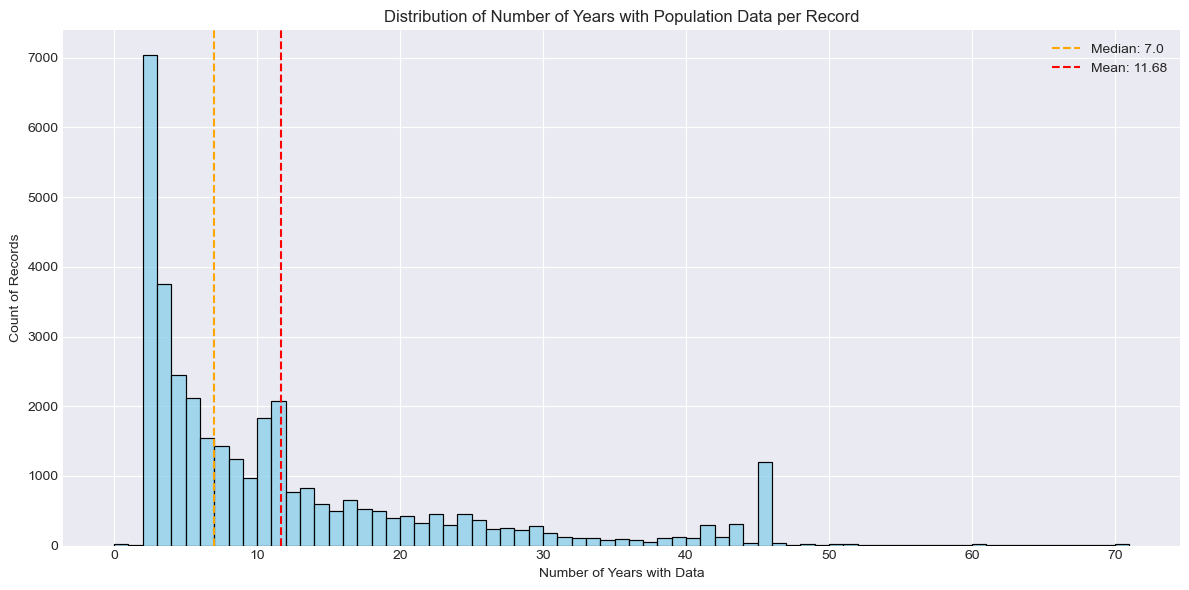


The histogram above shows how many records have population data for a certain number of years. For example, you can see how many records have data for 0 years, 1 year, 2 years, and so on. This helps us understand how complete the population data is across the dataset.


In [6]:
# Completeness: Records with at least some population data
df['has_population_data'] = df[year_cols].notna().any(axis=1)
df['n_years_with_data'] = df[year_cols].notna().sum(axis=1)

print(f"\nRecords with at least one population value: {df['has_population_data'].sum()} ({df['has_population_data'].sum()/len(df)*100:.1f}%)")
print(f"Records with NO population data: {(~df['has_population_data']).sum()} ({(~df['has_population_data']).sum()/len(df)*100:.1f}%)")

print("\nDistribution of Years with Data per Record:")
print(df['n_years_with_data'].describe().round(2))

# Plot distribution of years with data (only shows a few lables in x axis, but gives an idea of completeness)
# Show median and mean lines for reference
plt.figure(figsize=(12, 6))
sns.histplot(df['n_years_with_data'], bins=range(0, len(year_cols)+1), kde=False, color='skyblue')
plt.axvline(df['n_years_with_data'].median(), color='orange', linestyle='--', label=f'Median: {df["n_years_with_data"].median()}')
plt.axvline(df['n_years_with_data'].mean(), color='red', linestyle='--', label=f'Mean: {df["n_years_with_data"].mean():.2f}')
plt.title('Distribution of Number of Years with Population Data per Record')
plt.xlabel('Number of Years with Data')
plt.ylabel('Count of Records')
plt.legend()
plt.tight_layout()
plt.show()

# Print explanatio of plots in simple terms
print("\nThe histogram above shows how many records have population data for a certain number of years. For example, you can see how many records have data for 0 years, 1 year, 2 years, and so on. This helps us understand how complete the population data is across the dataset.")     

Populations with >=20 years of data and reaching 2020: 1151

Summary of maximum consecutive gaps:
count    1151.000000
mean       39.024327
std         8.992331
min         0.000000
25%        31.000000
50%        42.000000
75%        46.000000
max        51.000000
Name: max_consecutive_gaps, dtype: float64

Continuous populations (no gaps): 11
Populations with at least one gap: 1140


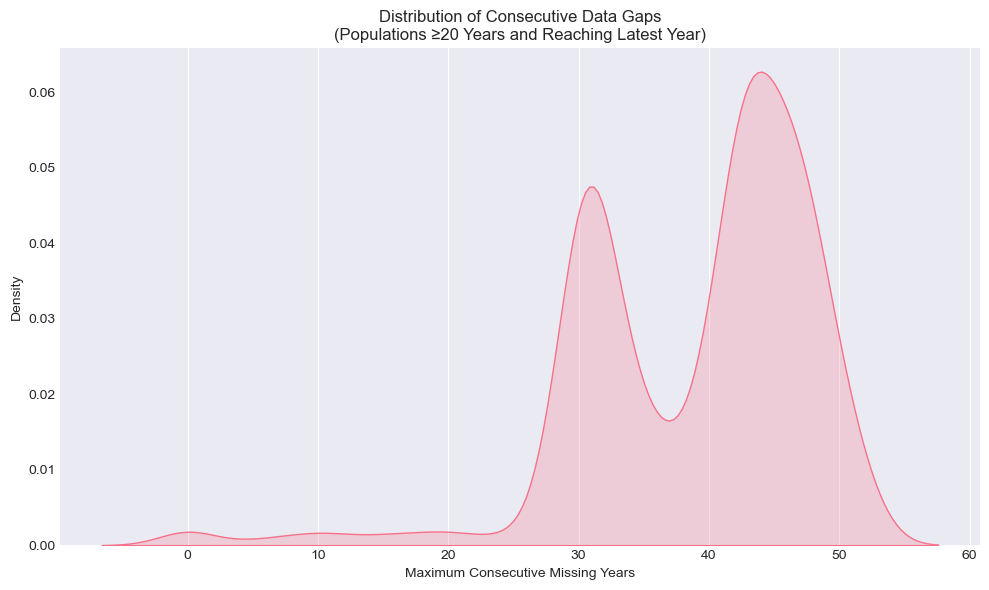

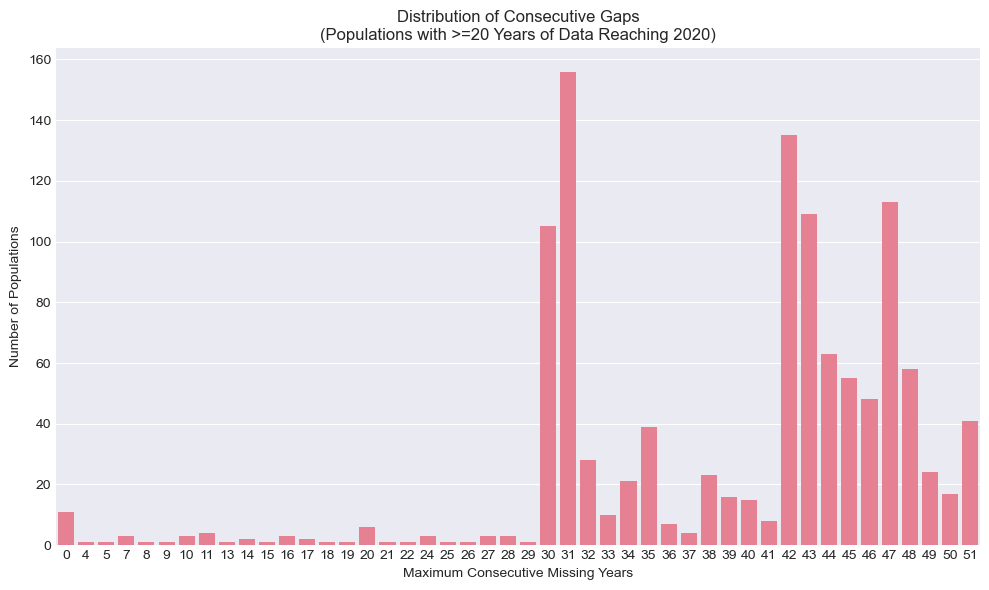

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assicurati che le colonne degli anni siano ordinate correttamente
year_cols = sorted(year_cols, key=int)

# Ultimo anno disponibile nel dataset
last_year = year_cols[-1]

# Conta quanti anni con dati ha ogni popolazione
df["n_years_with_data"] = df[year_cols].notna().sum(axis=1)

# Tieni solo le popolazioni con:
# - almeno 20 anni di dati
# - un valore presente anche nell'ultimo anno disponibile
usable_populations = df[
    (df["n_years_with_data"] >= 20) &
    (df[last_year].notna())
].copy()

print(f"Populations with >=20 years of data and reaching {last_year}: {len(usable_populations)}")

# Funzione per calcolare il massimo numero di anni consecutivi mancanti
def max_consecutive_gaps(row):
    gaps = row.isna().astype(int)

    max_gap = 0
    current_gap = 0

    for g in gaps:
        if g == 1:
            current_gap += 1
            max_gap = max(max_gap, current_gap)
        else:
            current_gap = 0

    return max_gap

# Calcola il massimo gap consecutivo per ogni popolazione
usable_populations["max_consecutive_gaps"] = usable_populations[year_cols].apply(
    max_consecutive_gaps, axis=1
)

# Stampa qualche statistica utile
print("\nSummary of maximum consecutive gaps:")
print(usable_populations["max_consecutive_gaps"].describe())

continuous = (usable_populations["max_consecutive_gaps"] == 0).sum()
print(f"\nContinuous populations (no gaps): {continuous}")
print(f"Populations with at least one gap: {len(usable_populations) - continuous}")

# =========================
# PLOT 1: distribuzione dei gap
# =========================
plt.figure(figsize=(10,6))

sns.kdeplot(
    usable_populations["max_consecutive_gaps"],
    fill=True
)

plt.title("Distribution of Consecutive Data Gaps\n(Populations ≥20 Years and Reaching Latest Year)")
plt.xlabel("Maximum Consecutive Missing Years")
plt.ylabel("Density")

plt.grid(axis="y")
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: conteggio esatto per gap
# =========================
gap_counts = usable_populations["max_consecutive_gaps"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=gap_counts.index, y=gap_counts.values)

plt.title(f"Distribution of Consecutive Gaps\n(Populations with >=20 Years of Data Reaching {last_year})")
plt.xlabel("Maximum Consecutive Missing Years")
plt.ylabel("Number of Populations")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


Top 5 species with highest overall increase rate:
                       Binomial first_year last_year  first_value  last_value  \
15370       Gadus_chalcogrammus       1963      2020    1524000.0   6900000.0   
5393        Gadus_chalcogrammus       1964      2020     489048.0   1925940.0   
15358  Micromesistius_poutassou       1981      2020    2840000.0   4150000.0   
15344       Gadus_chalcogrammus       1994      2020     785000.0   1753000.0   
1474      Pleuronectes_platessa       1957      2020     342000.0    905000.0   

       overall_increase_rate  
15370          153600.000000  
5393            41054.057143  
15358           37428.571429  
15344           27657.142857  
1474            16085.714286  


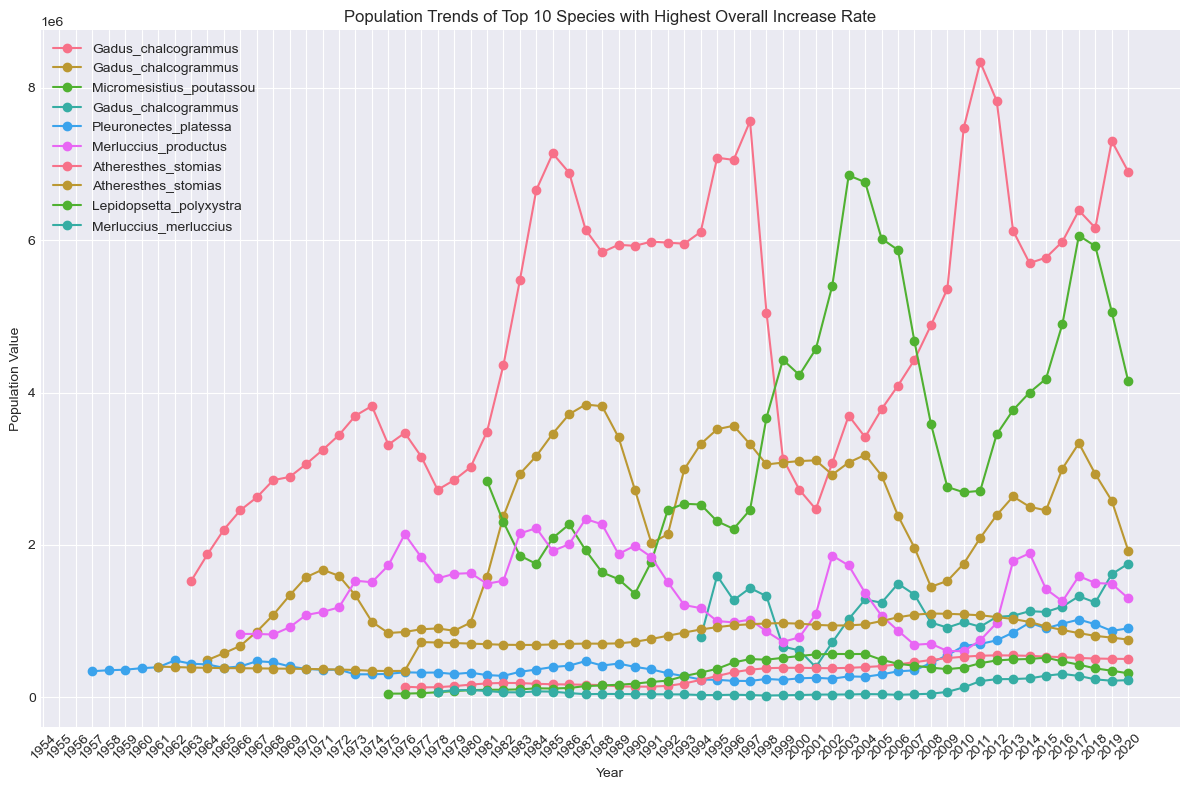

In [56]:
# Check species with the highest sudden increase rate over the entire time series (not just between two years, but overall trend)
usable_populations["first_year"] = usable_populations[year_cols].apply(lambda row: row.first_valid_index(), axis=1)
usable_populations["last_year"] = usable_populations[year_cols].apply(lambda row: row.last_valid_index(), axis=1)
usable_populations["first_value"] = usable_populations.apply(lambda row: row[row["first_year"]], axis=1)
usable_populations["last_value"] = usable_populations.apply(lambda row: row[row["last_year"]], axis=1)
usable_populations["overall_increase_rate"] = (usable_populations["last_value"] - usable_populations["first_value"]) / (int(usable_populations["last_year"].iloc[0]) - int(usable_populations["first_year"].iloc[0]))   
print("\nTop 5 species with highest overall increase rate:")
print(usable_populations.sort_values("overall_increase_rate", ascending=False)[["Binomial", "first_year", "last_year", "first_value", "last_value", "overall_increase_rate"]].head())   

# Plot 10 main species with highest overall increase rate as curves over time (only for those with at least 20 years of data and reaching the last year)
top_species = usable_populations.sort_values("overall_increase_rate", ascending=False).head(10)
plt.figure(figsize=(12, 8)) 
for _, row in top_species.iterrows():
    species_data = row[year_cols]
    plt.plot(year_cols, species_data, marker='o', label=row["Binomial"])
plt.title("Population Trends of Top 10 Species with Highest Overall Increase Rate")
plt.xlabel("Year")
plt.ylabel("Population Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Species & Geographic Distribution

In [7]:
# Species analysis
print("\nSpecies Distribution:")
print("-" * 80)
unique_species = df['Binomial'].nunique()
print(f"Unique Species: {unique_species}")
print(f"Average Replicates per Species: {len(df) / unique_species:.2f}")

print("\nTop 10 Most Replicated Species:")
species_counts = df['Binomial'].value_counts().head(10)
for species, count in species_counts.items():
    print(f"  {species:40} {count:3} records")

# Explain what replicates means in this context
print("\nExplanation of Replicates:")
print("Replicates refer to multiple observations or measurements of the same species within the dataset. This can occur when the same species is recorded across different locations, time periods, or studies.")       

# Geographic distribution
if 'Continent' in df.columns:
    print("\nDistribution by Continent:")
    print(df['Continent'].value_counts())

if 'Country' in df.columns:
    print(f"\nNumber of Countries: {df['Country'].nunique()}")
    print("\nTop 15 Countries:")
    print(df['Country'].value_counts().head(15))

# Explain what replicates means in this context
print("\nExplanation of Replicates:")
print("Replicates refer to multiple observations or measurements of the same species within the dataset. This can occur when the same species is recorded across different locations, time periods, or studies.")       



Species Distribution:
--------------------------------------------------------------------------------
Unique Species: 5177
Average Replicates per Species: 6.95

Top 10 Most Replicated Species:
  Calidris_ruficollis                      1083 records
  Tringa_nebularia                         879 records
  Limosa_lapponica                         829 records
  Calidris_acuminata                       777 records
  Calidris_ferruginea                      759 records
  Numenius_madagascariensis                696 records
  Calidris_tenuirostris                    451 records
  Charadrius_mongolus                      420 records
  Calidris_canutus                         416 records
  Xenus_cinereus                           362 records

Explanation of Replicates:
Replicates refer to multiple observations or measurements of the same species within the dataset. This can occur when the same species is recorded across different locations, time periods, or studies.

Number of Countries: 202

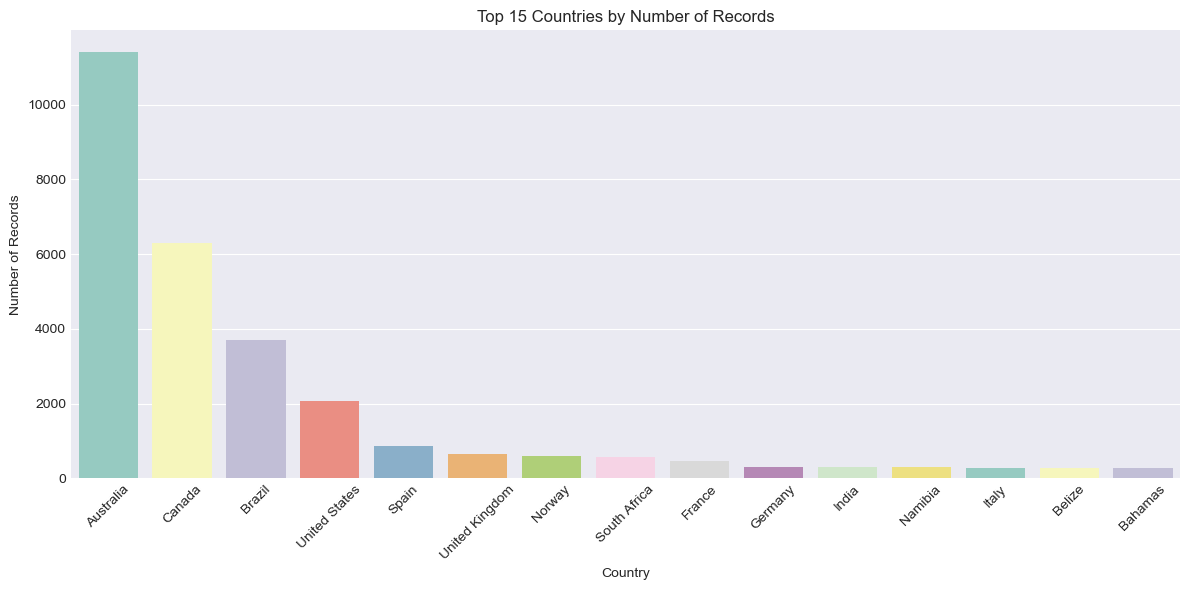

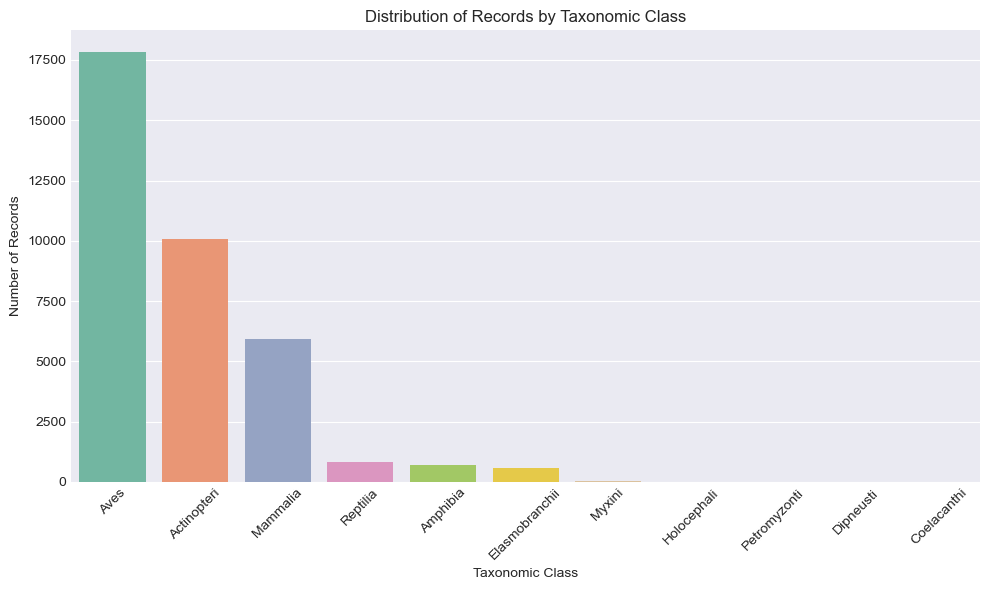

In [27]:
# Distribution of records by continent
if 'Continent' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='Continent', order=df['Continent'].value_counts().index, palette='Set2')
    plt.title('Distribution of Records by Continent')
    plt.xlabel('Continent')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Distribution of records by country (top 15)
if 'Country' in df.columns:
    plt.figure(figsize=(12, 6))
    top_countries = df['Country'].value_counts().head(15).index
    sns.countplot(data=df[df['Country'].isin(top_countries)], x='Country', order=top_countries, palette='Set3')
    plt.title('Top 15 Countries by Number of Records')
    plt.xlabel('Country')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Distribution of records by common name (top 15)
if 'Common name' in df.columns:
    plt.figure(figsize=(12, 6))
    top_common_names = df['Common name'].value_counts().head(15).index
    sns.countplot(data=df[df['Common name'].isin(top_common_names)], x='Common name', order=top_common_names, palette='Set1')
    plt.title('Top 15 Common Names by Number of Records')
    plt.xlabel('Common Name')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Distribution of records by Taxonomic Class (if available)
if 'Class' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='Class', order=df['Class'].value_counts().index, palette='Set2')
    plt.title('Distribution of Records by Taxonomic Class')
    plt.xlabel('Taxonomic Class')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

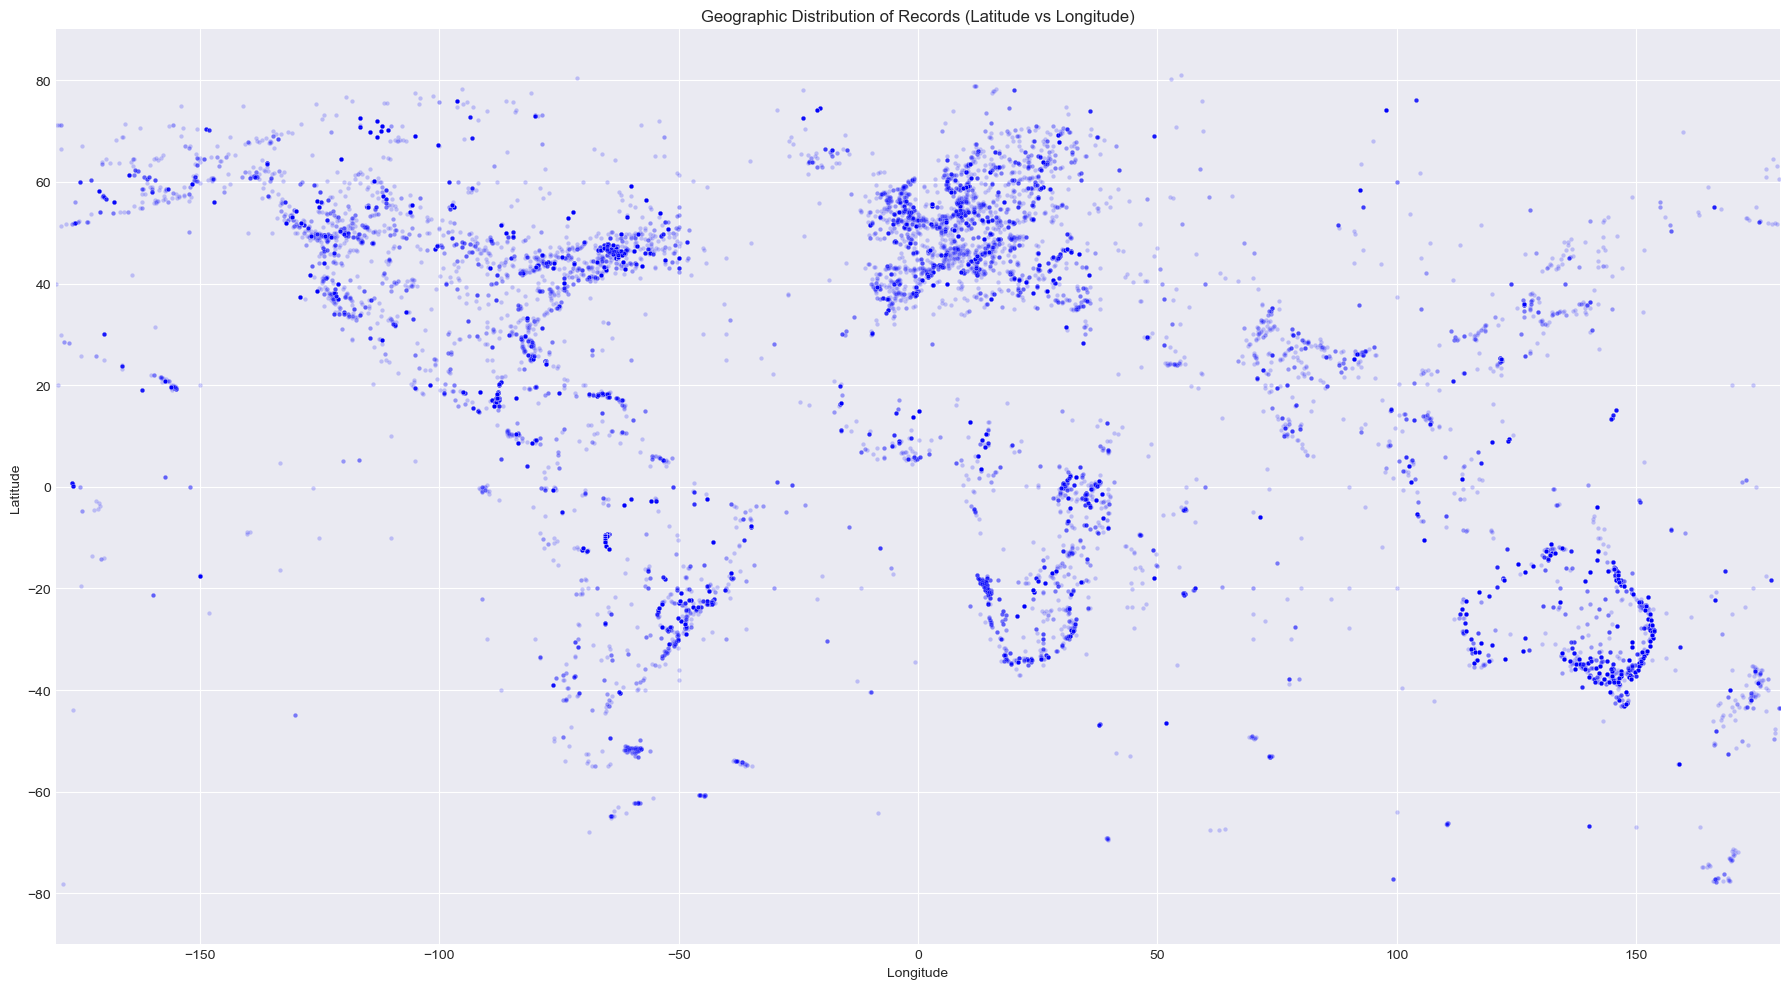

In [35]:
# Plot geographic distribution (coordinates scatter, small dots with some transparency to show density)
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    plt.figure(figsize=(18, 10))
    sns.scatterplot(data=df, x='Longitude', y='Latitude', alpha=0.2, s=10, color='blue')
    plt.title('Geographic Distribution of Records (Latitude vs Longitude)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    plt.tight_layout()
    plt.show()

## 4. Temporal Analysis - Time Series Coverage

In [8]:
# Temporal coverage
print("\nTemporal Coverage Analysis:")
print("-" * 80)

# Explain what temporal coverage means in simple terms
print("\nTemporal coverage refers to how many records have population data for each year. It helps us understand which years have more complete data and which years have more missing values. This is important for analyzing trends over time and for making predictions about future population changes.")
# Count non-null values per year (+ percentage with 2 decimal places)
temporal_coverage = pd.DataFrame({
    'Year': sorted(year_cols),
    'Count': [df[year].notna().sum() for year in sorted(year_cols)], # round percentage to 2 decimal places
    'Percentage': [(df[year].notna().sum() / len(df)) * 100 for year in sorted(year_cols)]
})

print(temporal_coverage.to_string(index=False))

print(f"\nEarliest Year with Data: {temporal_coverage[temporal_coverage['Count'] > 0].iloc[0]['Year']}")
print(f"Latest Year with Data: {temporal_coverage[temporal_coverage['Count'] > 0].iloc[-1]['Year']}")
print(f"Peak Data Collection: {temporal_coverage.loc[temporal_coverage['Count'].idxmax(), 'Year']} ({temporal_coverage['Count'].max()} records)")


Temporal Coverage Analysis:
--------------------------------------------------------------------------------

Temporal coverage refers to how many records have population data for each year. It helps us understand which years have more complete data and which years have more missing values. This is important for analyzing trends over time and for making predictions about future population changes.
Year  Count  Percentage
1950    265    0.736193
1951    245    0.680631
1952    290    0.805645
1953    285    0.791755
1954    303    0.841760
1955    325    0.902878
1956    371    1.030670
1957    340    0.944549
1958    382    1.061229
1959    427    1.186243
1960    607    1.686298
1961    648    1.800200
1962    660    1.833537
1963    691    1.919658
1964    751    2.086343
1965    863    2.397489
1966    876    2.433604
1967   1040    2.889210
1968   1064    2.955884
1969   1112    3.089232
1970   3476    9.656629
1971   3408    9.467719
1972   3562    9.895544
1973   3987   11.07623

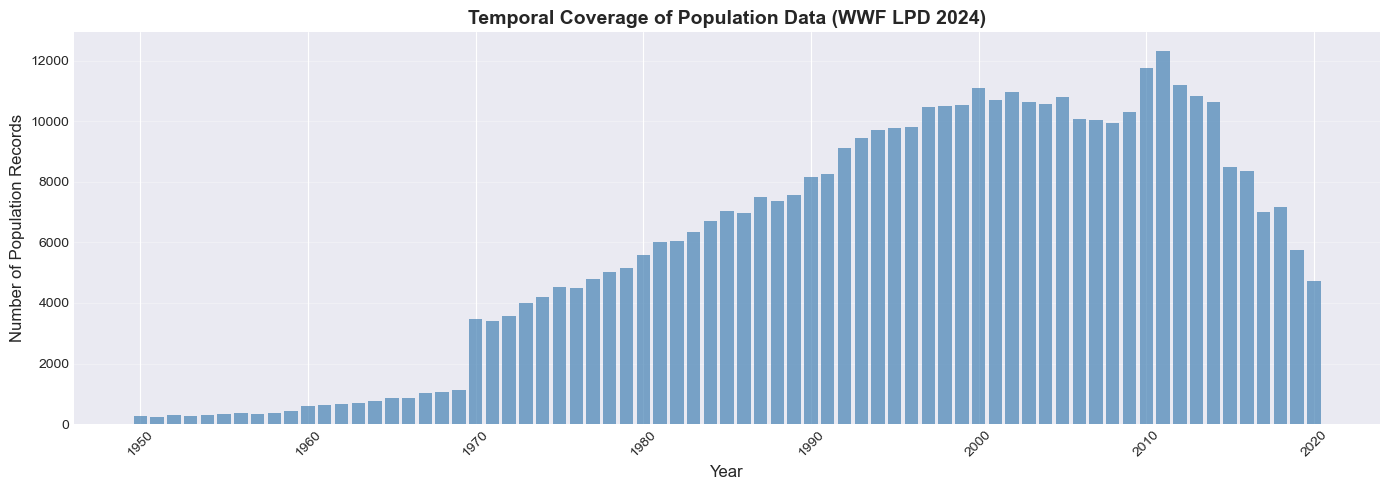

Data availability peaks in recent decades with trend toward more complete coverage


In [9]:
# Visualize temporal coverage 
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(temporal_coverage['Year'].astype(int), temporal_coverage['Count'], color='steelblue', alpha=0.7)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Population Records', fontsize=12)
ax.set_title('Temporal Coverage of Population Data (WWF LPD 2024)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Data availability peaks in recent decades with trend toward more complete coverage")

## 5. Population Trends & Statistical Patterns

In [10]:
# Population statistics across all years
print("\nPopulation Statistics (Pooled Across All Years):")
print("-" * 80)
all_pop_values = df[year_cols].values.flatten()
all_pop_values_clean = all_pop_values[~np.isnan(all_pop_values)]

print(f"Total Population Values: {len(all_pop_values_clean)}")
print(f"Min: {np.nanmin(all_pop_values_clean):.2e}")
print(f"Max: {np.nanmax(all_pop_values_clean):.2e}")
print(f"Mean: {np.nanmean(all_pop_values_clean):.2e}")
print(f"Std Dev: {np.nanstd(all_pop_values_clean):.2e}")
print(f"Median: {np.nanmedian(all_pop_values_clean):.2e}")

# Check for zero/negative values
zeros = (all_pop_values_clean == 0).sum()
negative = (all_pop_values_clean < 0).sum()
print(f"\nZero values: {zeros}")
print(f"Negative values: {negative}")

# Log-scale statistics (common for population data)
positive_values = all_pop_values_clean[all_pop_values_clean > 0]
print(f"\nLog-scale Statistics (positive values only):")
print(f"Count: {len(positive_values)}")
print(f"Log10 Mean: {np.log10(positive_values).mean():.2f}")
print(f"Log10 Std Dev: {np.log10(positive_values).std():.2f}")


Population Statistics (Pooled Across All Years):
--------------------------------------------------------------------------------
Total Population Values: 420356
Min: 0.00e+00
Max: 2.50e+15
Mean: 1.17e+11
Std Dev: 1.31e+13
Median: 5.00e+00

Zero values: 62002
Negative values: 0

Log-scale Statistics (positive values only):
Count: 358354
Log10 Mean: 1.28
Log10 Std Dev: 1.84


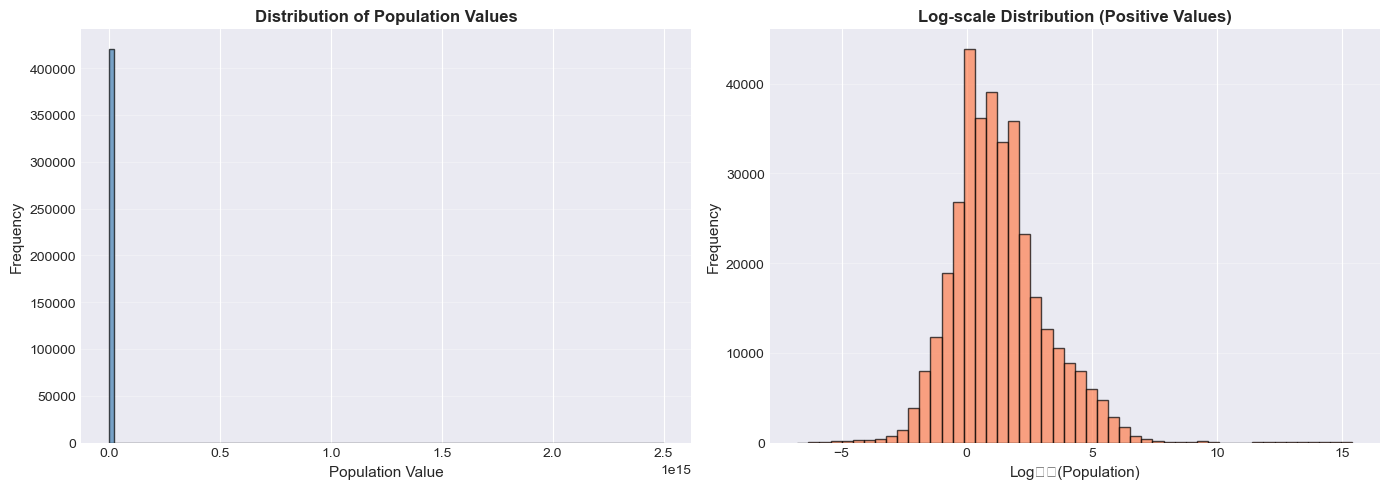

Population values span multiple orders of magnitude, suggesting log-scale transformation may be beneficial for forecasting


In [11]:
# Distribution of population values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(all_pop_values_clean, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Population Value', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Population Values', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Log-scale histogram (for positive values)
axes[1].hist(np.log10(positive_values), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Log₁₀(Population)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Log-scale Distribution (Positive Values)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Population values span multiple orders of magnitude, suggesting log-scale transformation may be beneficial for forecasting")

In [12]:
# Time series trends - aggregate statistics per year
print("\nYear-by-Year Population Statistics:")
print("-" * 80)

yearly_stats = []
for year in sorted(year_cols):
    values = df[year].dropna()
    if len(values) > 0:
        yearly_stats.append({
            'Year': int(year),
            'Count': len(values),
            'Mean': values.mean(),
            'Median': values.median(),
            'Std': values.std(),
            'Min': values.min(),
            'Max': values.max()
        })

yearly_df = pd.DataFrame(yearly_stats)
print(yearly_df.to_string(index=False))


Year-by-Year Population Statistics:
--------------------------------------------------------------------------------
 Year  Count         Mean     Median          Std  Min          Max
 1950    265 9.441820e+12 243.000000 1.535733e+14  0.0 2.500000e+15
 1951    245 1.004931e+13 353.000000 1.571631e+14  0.0 2.460000e+15
 1952    290 8.351971e+12 281.500000 1.421069e+14  0.0 2.420000e+15
 1953    285 8.287969e+12 294.000000 1.397940e+14  0.0 2.360000e+15
 1954    303 7.597560e+12 323.000000 1.321312e+14  0.0 2.300000e+15
 1955    325 7.093693e+12 191.700000 1.237523e+14  0.0 2.230000e+15
 1956    371 5.991778e+12 300.000000 1.116729e+14  0.0 2.150000e+15
 1957    340 6.260409e+12 490.000000 1.117665e+14  0.0 2.060000e+15
 1958    382 5.324943e+12 295.500000 1.008355e+14  0.0 1.970000e+15
 1959    427 4.496528e+12 300.000000 9.004869e+13  0.0 1.860000e+15
 1960    607 2.974806e+12 350.000000 7.106005e+13  0.0 1.750000e+15
 1961    648 2.593822e+12 458.500000 6.405810e+13  0.0 1.630000e+1

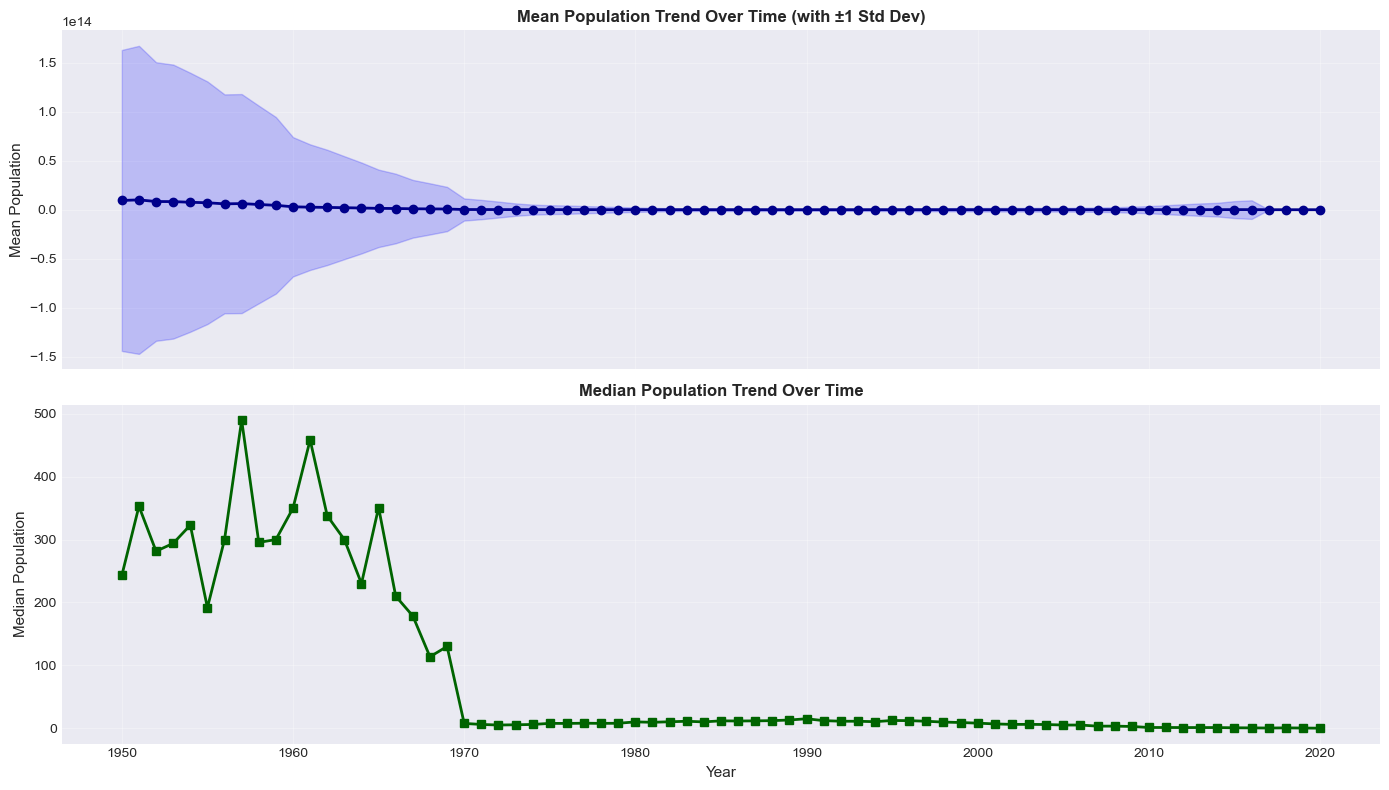

In [13]:
# Trends visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Mean population over time
axes[0].plot(yearly_df['Year'], yearly_df['Mean'], marker='o', linewidth=2, markersize=6, color='darkblue')
axes[0].fill_between(yearly_df['Year'], 
                      yearly_df['Mean'] - yearly_df['Std'], 
                      yearly_df['Mean'] + yearly_df['Std'], 
                      alpha=0.2, color='blue')
axes[0].set_ylabel('Mean Population', fontsize=11)
axes[0].set_title('Mean Population Trend Over Time (with ±1 Std Dev)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xticklabels([])

# Median population over time
axes[1].plot(yearly_df['Year'], yearly_df['Median'], marker='s', linewidth=2, markersize=6, color='darkgreen')
axes[1].set_ylabel('Median Population', fontsize=11)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_title('Median Population Trend Over Time', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Sample Time Series Analysis - Population Trajectories


Records with ≥10 years of data: 15430 (42.9%)


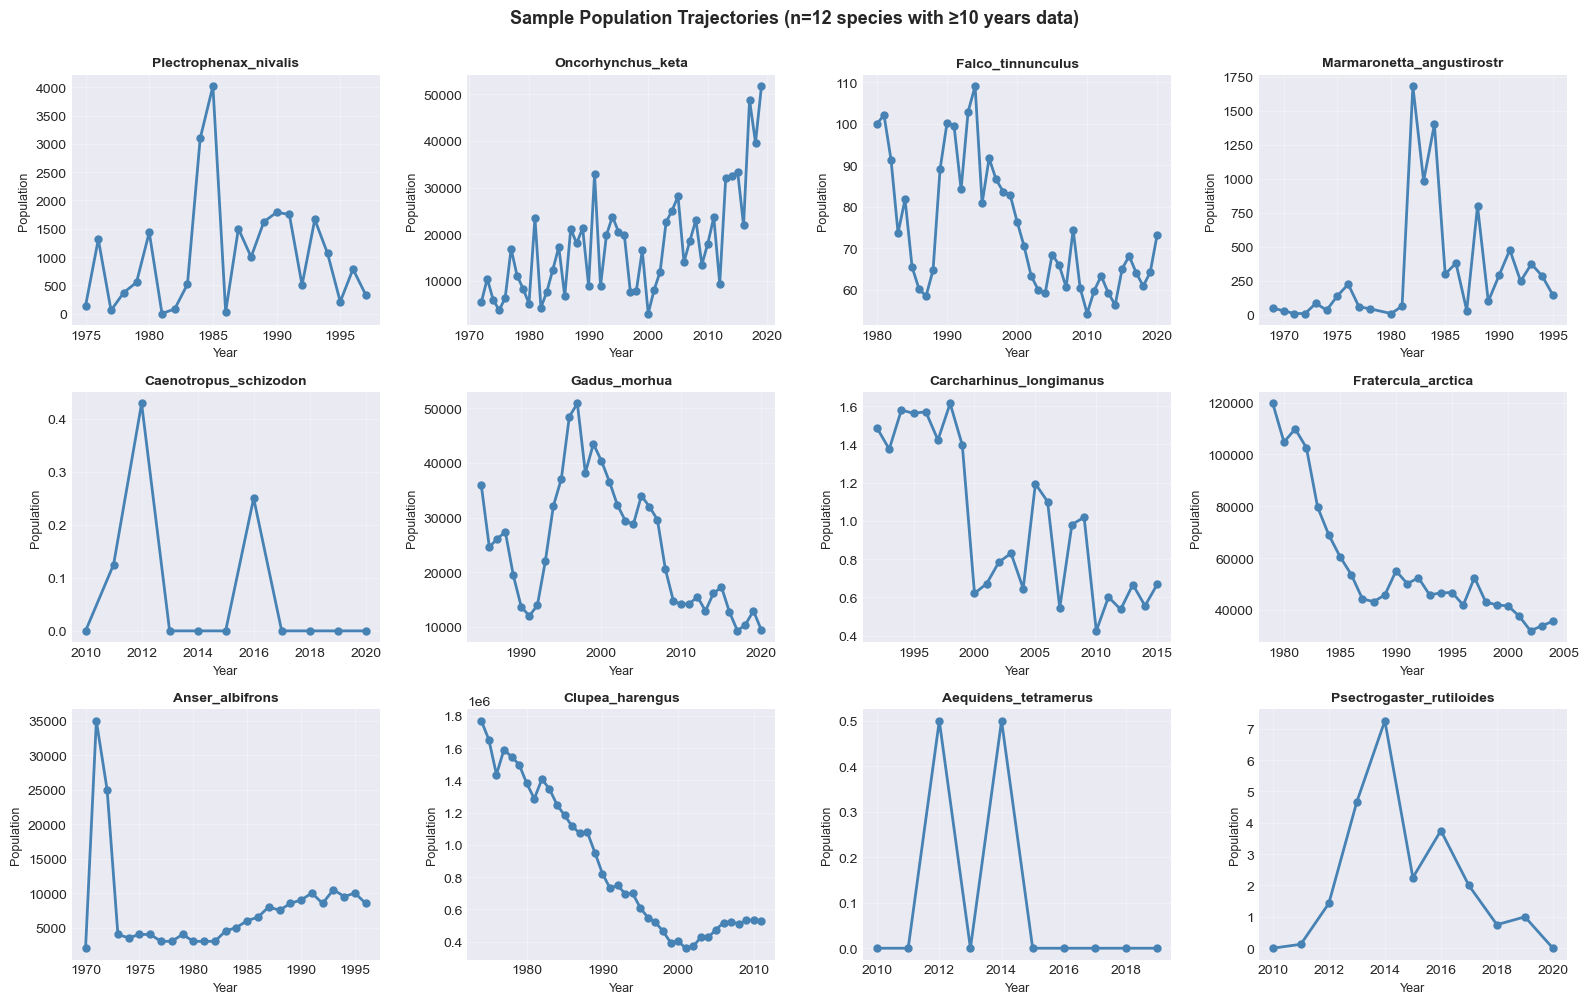

In [14]:
# Filter records with substantial time series data (for forecasting)
min_years_threshold = 10
df_forecasting = df[df['n_years_with_data'] >= min_years_threshold].copy()

print(f"\nRecords with ≥{min_years_threshold} years of data: {len(df_forecasting)} ({len(df_forecasting)/len(df)*100:.1f}%)")

if len(df_forecasting) > 0:
    # Sample and visualize individual trajectories
    sample_indices = np.random.choice(df_forecasting.index, min(12, len(df_forecasting)), replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, ax in enumerate(axes):
        if idx < len(sample_indices):
            record_idx = sample_indices[idx]
            species = df.loc[record_idx, 'Binomial']
            
            # Get population data
            pop_data = df.loc[record_idx, year_cols]
            years = [int(y) for y in year_cols]
            
            # Filter to years with data
            mask = pop_data.notna()
            years_with_data = [y for y, m in zip(years, mask) if m]
            pop_with_data = pop_data[mask].values
            
            if len(years_with_data) > 0:
                ax.plot(years_with_data, pop_with_data, marker='o', linewidth=2, markersize=5, color='steelblue')
                ax.set_title(f"{species[:25]}", fontsize=10, fontweight='bold')
                ax.set_xlabel('Year', fontsize=9)
                ax.set_ylabel('Population', fontsize=9)
                ax.grid(alpha=0.3)
        else:
            ax.axis('off')
    
    plt.suptitle(f'Sample Population Trajectories (n={len(sample_indices)} species with ≥{min_years_threshold} years data)', 
                 fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print(f"No records with ≥{min_years_threshold} years of data found.")

## 7. Key Features & Dimensions for Forecasting

In [15]:
# Identify categorical variables that could be predictors
print("\nKey Dimensions for Forecasting:")
print("-" * 80)

potential_features = []
for col in df.columns:
    if col not in year_cols and col not in ['ID', 'Unnamed: 102'] and df[col].dtype == 'object':
        unique_count = df[col].nunique()
        if unique_count < 1000:  # Reasonable number of categories
            potential_features.append((col, unique_count))
            print(f"\n{col}:")
            print(f"  Unique Values: {unique_count}")
            print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")
            if unique_count <= 10:
                print(f"  Values: {df[col].unique()[:10].tolist()}")
            else:
                print(f"  Examples: {df[col].unique()[:5].tolist()}")


Key Dimensions for Forecasting:
--------------------------------------------------------------------------------

Class:
  Unique Values: 11
  Missing: 0 (0.0%)
  Examples: ['Aves', 'Mammalia', 'Reptilia', 'Amphibia', 'Actinopteri']

Order:
  Unique Values: 134
  Missing: 0 (0.0%)
  Examples: ['Gruiformes', 'Passeriformes', 'Falconiformes', 'Galliformes', 'Accipitriformes']

Family:
  Unique Values: 647
  Missing: 0 (0.0%)
  Examples: ['Gruidae', 'Acrocephalidae', 'Muscicapidae', 'Falconidae', 'Phasianidae']

Subspecies:
  Unique Values: 343
  Missing: 33232 (92.3%)
  Examples: [nan, 'cokii', 'major', 'swaynei', 'cottoni']

Country:
  Unique Values: 202
  Missing: 0 (0.0%)
  Examples: ['Uganda', 'Seychelles', 'Mauritius', 'Djibouti', 'Botswana']

All_countries:
  Unique Values: 597
  Missing: 0 (0.0%)
  Examples: ['Uganda', 'Seychelles', 'Mauritius', 'Djibouti', 'Botswana']

Region:
  Unique Values: 8
  Missing: 0 (0.0%)
  Values: ['Africa', 'Oceania', 'North America', 'Asia', 'Latin 

In [16]:
# Summary statistics for record-level integer columns
print("\n\nNumeric Features:")
print("-" * 80)
numeric_cols = df.select_dtypes(include=['int64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['ID']]

for col in numeric_cols:
    print(f"\n{col}:")
    print(df[col].describe())



Numeric Features:
--------------------------------------------------------------------------------

Replicate:
count    35996.000000
mean         0.164991
std          0.371177
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Replicate, dtype: float64

Included in LPR2024:
count    35996.000000
mean         0.823036
std          0.381644
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Included in LPR2024, dtype: float64

Specific_location:
count    35996.000000
mean         0.386599
std          0.486977
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Specific_location, dtype: float64

Native:
count    35996.000000
mean         0.989082
std          0.103918
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Native, dtyp

## 8. Conclusions & Next Steps for Population Forecasting Model

In [17]:
print("=" * 80)
print("SUMMARY & INSIGHTS FOR POPULATION FORECASTING")
print("=" * 80)

summary = f"""
📊 DATA OVERVIEW:
  • {len(df):,} population time series records
  • {unique_species} unique species
  • Time range: {min(year_cols)} - {max(year_cols)} ({len(year_cols)} years)
  • Geographic coverage: {df['Continent'].nunique() if 'Continent' in df.columns else 'N/A'} continents

⏱️ TEMPORAL CHARACTERISTICS:
  • {len(df_forecasting):,} records suitable for forecasting (≥{min_years_threshold} years)
  • Data quality peaks in recent decades
  • Early years (1950s-1980s) have sparser coverage
  • Recent years show increasing data collection

📈 POPULATION PATTERNS:
  • Values span 8+ orders of magnitude (log-scale modeling recommended)
  • Many species show non-linear trends
  • High variability in trends across species
  • {zeros} zero values, {negative} negative values detected

🎯 RECOMMENDED FORECASTING APPROACHES:
  1. Time Series Models (ARIMA, Exponential Smoothing) - for univariate forecasting
  2. Hierarchical/Multilevel Models - to account for species-level heterogeneity
  3. Log-transformation - to handle scale variations
  4. Filtering Strategy - focus on records with sufficient historical data
  5. Uncertainty Quantification - critical given data sparsity

⚠️ DATA QUALITY CONSIDERATIONS:
  • {(~df['has_population_data']).sum():,} records with NO population data
  • Highly unbalanced temporal coverage
  • Missing data increases backward in time
  • May need to handle replicate records appropriately

➡️ NEXT STEPS:
  1. Select forecasting subset (species with ≥{min_years_threshold} years continuous data)
  2. Prepare data: handling replicates, log-transform, train-test split
  3. Develop baseline models and estimate forecast uncertainty
  4. Validate against held-out test periods
  5. Analyze which features/species are most predictable
"""

print(summary)

SUMMARY & INSIGHTS FOR POPULATION FORECASTING

📊 DATA OVERVIEW:
  • 35,996 population time series records
  • 5177 unique species
  • Time range: 1950 - 2020 (71 years)
  • Geographic coverage: N/A continents

⏱️ TEMPORAL CHARACTERISTICS:
  • 15,430 records suitable for forecasting (≥10 years)
  • Data quality peaks in recent decades
  • Early years (1950s-1980s) have sparser coverage
  • Recent years show increasing data collection

📈 POPULATION PATTERNS:
  • Values span 8+ orders of magnitude (log-scale modeling recommended)
  • Many species show non-linear trends
  • High variability in trends across species
  • 62002 zero values, 0 negative values detected

🎯 RECOMMENDED FORECASTING APPROACHES:
  1. Time Series Models (ARIMA, Exponential Smoothing) - for univariate forecasting
  2. Hierarchical/Multilevel Models - to account for species-level heterogeneity
  3. Log-transformation - to handle scale variations
  4. Filtering Strategy - focus on records with sufficient historical data

# WWF Living Planet Database – Key Insights from EDA

This document summarizes the **main insights emerging from the two exploratory data analyses (EDA)** conducted on the **WWF Living Planet Database 2024**.  
The goal is to identify **converging findings**, highlight **implications for modeling**, and align the team on possible **machine learning directions**.

---

## 1. Dataset Overview and General Structure

Both notebooks analyse the **WWF Living Planet Database 2024**, which contains approximately:

- **35,996 records**
- **103 columns**
- **~71 temporal columns (1950–2020)**

This dataset is sufficiently large and rich for **machine learning applications**.

### Data structure

- ~74 numeric columns  
- ~24 categorical columns  
- ~5 integer columns  

Both analyses correctly identify three main feature groups:

- **Taxonomic columns**
- **Geographical columns**
- **Temporal columns (year columns)**

> This structure provides a strong basis for **time-series modelling combined with spatial features**.

---

## 2. Data Quality Insights

### High missingness in year columns

Many year columns contain **>99% missing values**.

However, this is **structural rather than erroneous**, because:

- each record represents a **partial time series**

EDA statistics show:

- **Mean years per record ≈ 11.7**
- **Median ≈ 7**
- **Maximum = 71**

> The dataset is therefore a **sparse longitudinal panel dataset**.

### Implications

Forecasting is feasible, but:

- very short time series may not be useful for modelling

Possible filtering thresholds:

- **≥ 10 years**
- **≥ 15 years**
- **≥ 20 years** *(I would opt for this one)*

---

## 3. Temporal Coverage

A clear trend emerges:

> **More observations exist in recent decades.**

### Distribution by decade

| Decade | Coverage |
|--------|----------|
| 1950s  | ~1.7%    |
| 1960s  | ~4.5%    |
| 1970s  | ~20%     |
| 1980s  | ~32%     |
| 1990s  | ~53%     |
| 2000s  | ~60%     |
| 2010s  | ~53%     |

### Key insight

The dataset is **biased toward recent decades**.

### Implications for forecasting

- The model may learn patterns mostly from **recent ecological dynamics**  
  *(but these have also been changing quite exponentially over the last 5 years, and it is reasonable to assume they will continue changing in the future)*
- Care must be taken to avoid **temporal leakage** when splitting the dataset  
  *(split time series chronologically)*

---

## 4. Biodiversity Coverage

The dataset contains approximately:

- **5,177 species**

**N.B.**: each entry is **not a species**, but a **record** (i.e. a local population studied).  
This means there can be multiple records belonging to the **same species** in different parts of the world.

Taxonomic distribution is **highly imbalanced**.

### Most represented classes

| Class         | Records |
|---------------|---------|
| Aves          | ~17k    |
| Actinopteri   | ~10k    |
| Mammalia      | ~5.9k   |

Much fewer observations exist for:

- reptiles
- amphibians
- sharks

> The dataset is **taxonomically imbalanced**.

### Possible strategies

- Train **models per taxonomic class**
- Include **taxonomic features** as model inputs
- Train model on **species**
- Train model on **populations** (not species)

---

## 5. Spatial Coverage

Geographic coordinates are available for **100% of records**.

### Coordinate ranges

- **Latitude:** -78 → 81  
- **Longitude:** -180 → 180

### Why this is valuable

This enables:

- spatial modelling
- integration with environmental datasets
- region clustering
- geographic trend analysis

> Spatial information could be central to the **deployable application**.

---

## 6. Population Value Distribution

### Critical issue: extreme variation

Population values show extreme variation:

- **Min = 0**
- **Max ≈ 2.5 × 10¹⁵**

Summary statistics:

- **Median ≈ 5**
- **Mean ≈ 1 × 10¹¹**

This indicates an **extremely skewed distribution**.

Most observations are **very small**, while a few are **extremely large**.

Visualisations confirm a **heavy-tailed distribution**.

### Implication

> A **log transformation** is likely necessary for modelling.

Example:

`log(population + 1)`

---

## 7. Zero Values

Approximately:

- **14.7% of population values are zero**

### Possible interpretations

- local extinction
- missing observations encoded as zero
- survey failing to detect individuals

### Implications

This may require modelling approaches such as:

- **zero-inflated models**
- **classification + regression approaches**

---

## 8. Replicates per Species

On average:

- **~7 replicates per species**

### Meaning

The same species is often observed in:

- multiple populations
- multiple locations
- different monitoring studies

### Example

- same species
- different geographic populations
- different monitoring studies

### Opportunities

This structure allows:

- **hierarchical modelling**
- **species-level feature learning**
- **cross-population trend analysis**

---

## 9. Main Machine Learning Directions

The dataset supports several potential ML problems.

### A — Population Forecasting

**Inputs:**

- species
- location
- historical population values

**Output:**

- **future population**

### B — Biodiversity Decline Detection

**Target:**

- classify **decline vs growth**

### C — Extinction Risk Early Warning

**Prediction:**

- probability of **population collapse**

---

## 10. Key Insights (Short Version)

The most important findings to bring into the project are:

1. The dataset is rich but **time series are sparse**
2. There is a strong **temporal bias toward recent decades**
3. Population values are **extremely skewed**
4. The dataset is **taxonomically imbalanced**
5. Geographic coverage is **global and complete**
6. Multiple **replicates exist per species**

---

## 11. Implications for Machine Learning

### Preprocessing

Possible steps:

- `log(population + 1)` *(especially if species varies a lot — check plots)*
- filter short time series

### Problems to handle

- Handle **temporal gaps** for potentially usable populations  
  - either use `Δyears` as a feature  
  - or interpolate  
  - or filter again using regular series and impute others
  - be aware that some populations might have just reached zero cause they're almsot extinct

- WWF usually uses **relative trends** rather than absolute numbers:  
  they provide information on **how the population changes**, so perhaps we can consider using:

  - **trend / growth rate**, namely  
    `log(pop_t) − log(pop_t−1)`  
    or equivalent growth-based transformations

- **Geographical bias** *(most data from Europe)*  
  - the model might learn **sampling patterns**, not biological patterns  
  - mitigate by including **latitude / longitude / biome** as features

- **Problem / opportunity**:  
  the dataset has **multiple populations of the same species in different places**, so it can learn something more powerful and insightful:

  - **decline early warning**
  - if the model sees that populations of the same species are declining in different places, it warns the user anyway, even if that specific population does not yet seem to be declining
  - this is potentially **very strong for the SDG project**

### Potential features

- taxonomic features
- geographic features
- temporal trends
- lagged population values

### Possible models

#### Baseline models

- Linear Regression
- Random Forest

#### More advanced approaches

- XGBoost
- LSTM
- Temporal CNN

---

## 12. Additional Analyses Missing from Current EDA

Before modelling, additional analyses could strengthen the project.

### 12.1 Population Growth Rates

Compute:

- `log(pop_t+1) − log(pop_t)`

This would help measure:

- population growth
- population decline

Why useful:

- more stable
- less dependent on initial size
- more interpretable

### 12.2 Decline Frequency

Estimate:

- percentage of populations showing **decline**

### 12.3 Spatial Hotspots of Decline

Identify geographic areas with:

- higher rates of population decline

### 12.4 Time Series Clustering

Cluster populations by dynamics:

- declining
- recovering
- stable

---

## 13. Next Possible Steps

To align the team, the following could be developed.

### 13.1 Unified EDA Insights Document

Structured sections:

- dataset overview
- data quality
- temporal coverage
- spatial structure
- biodiversity distribution
- modelling implications

### 13.2 Strong Research Question

Clearly link the modelling task to the **Sustainable Development Goals (SDGs)**.

### 13.3 Modelling Strategy

A step-by-step modelling plan covering:

- preprocessing  
  *(clean, filter, impute based on rationale, convert to long format)*

- feature engineering  
  *(log populations, growth rate, lag features)*

- model selection  
  *(baseline Random Forest or XGBoost)*

- prediction target  
  *(specific population or growth rate)*

- grouping strategy  
  - if we have a map: **population-level**
  - if not: **group per species**

- evaluation
- deployment

- dashboard idea:  
  click on a population/species and generate:
  - selected prediction
  - info on species
  - trend graph

---

## 14. In the Presentation

### Limitations

*(to be explicitly discussed)*

### General + Spatial + Temporal Analysis

*(to be structured clearly in the presentation)*

### Application Usage

**User inserts:**

- species
- location
- last `n` years for a given population

**The system:**

- uses models
- predicts future trend

**Output:**

- population prediction
- decline risk
- trend visualization

> This meets the **deployment requirements of the challenge description**.